# 03 Experiments

Цель: сравнение моделей и анализ итоговой таблицы экспериментов

In [13]:
from pathlib import Path
import pandas as pd

ROOT = Path('..')
exp_path = ROOT / 'report' / 'experiments.csv'
exp = pd.read_csv(exp_path)
exp

,model,feature_set,val_mae,val_rmse,test_mae,test_rmse
0,xgb_random_search,full_features,15.633555,23.304600,21.795045,31.431404
1,xgb_small,full_features,15.806416,23.461429,22.258149,31.579211
2,xgboost,full_features,16.202579,24.513323,24.140998,34.813212
3,rf_random_search,full_features,16.449774,25.010224,23.025811,33.439694
4,random_forest,full_features,16.536519,25.258557,23.216536,33.897146
5,rf_200,full_features,16.712222,25.426088,23.351569,33.946098
6,baseline_linear,full_features,37.083122,49.153719,35.808042,46.753875
7,ridge,full_features,37.309061,49.574720,35.759471,46.809773
8,knn,full_features,45.472015,58.807153,68.175265,90.510881
9,baseline_raw_linear,raw_only,114.783123,139.735550,137.173501,167.524804


In [14]:
exp.sort_values('val_mae').reset_index(drop=True)

,model,feature_set,val_mae,val_rmse,test_mae,test_rmse
0,xgb_random_search,full_features,15.633555,23.304600,21.795045,31.431404
1,xgb_small,full_features,15.806416,23.461429,22.258149,31.579211
2,xgboost,full_features,16.202579,24.513323,24.140998,34.813212
3,rf_random_search,full_features,16.449774,25.010224,23.025811,33.439694
4,random_forest,full_features,16.536519,25.258557,23.216536,33.897146
5,rf_200,full_features,16.712222,25.426088,23.351569,33.946098
6,baseline_linear,full_features,37.083122,49.153719,35.808042,46.753875
7,ridge,full_features,37.309061,49.574720,35.759471,46.809773
8,knn,full_features,45.472015,58.807153,68.175265,90.510881
9,baseline_raw_linear,raw_only,114.783123,139.735550,137.173501,167.524804


In [15]:
best = exp.sort_values('val_mae').iloc[0]
print('best model:', best['model'])
print('feature_set:', best['feature_set'])
print('val_mae:', best['val_mae'])
print('test_mae:', best['test_mae'])

best model: xgb_random_search
feature_set: full_features
val_mae: 15.633555371920773
test_mae: 21.79504482256471


Полное обучение и пересчёт таблицы выполняется скриптом `src/modeling.py`.

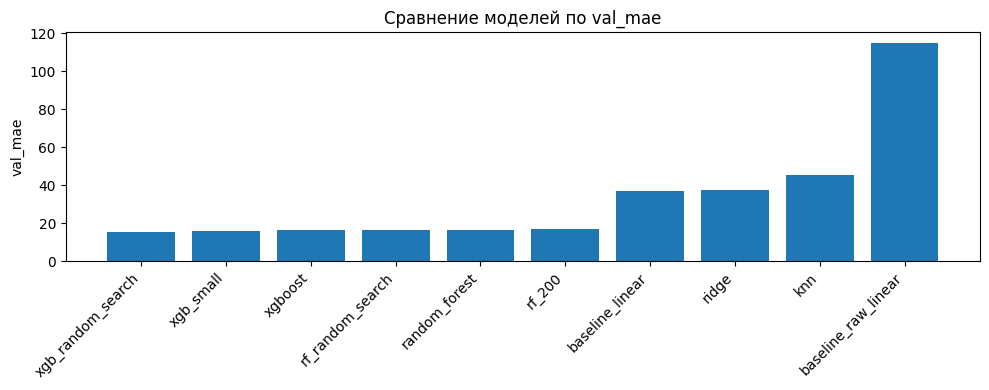

In [16]:
import matplotlib.pyplot as plt

view = exp.sort_values('val_mae').copy()
plt.figure(figsize=(10, 4))
plt.bar(view['model'], view['val_mae'])
plt.xticks(rotation=45, ha='right')
plt.title('Сравнение моделей по val_mae')
plt.ylabel('val_mae')
plt.tight_layout()
plt.show()

`xgb_small` дает лучший `val_mae`, а `baseline_raw_linear` сильно хуже, что также подтверждает важность feature engineering

In [17]:
from pathlib import Path
import json

ROOT = Path('..')
best_info = json.loads((ROOT / 'report' / 'best_model_info.json').read_text(encoding='utf-8'))
best_info

{'best_model': 'xgb_random_search', 'selection_metric': 'val_mae'}

In [18]:
exp.groupby('feature_set')[['val_mae', 'test_mae']].mean().sort_values('val_mae')

,val_mae,test_mae
feature_set,,
full_features,24.133918,30.836765
raw_only,114.783123,137.173501


In [19]:
cmp = exp[['model', 'val_mae', 'test_mae']].sort_values('val_mae').reset_index(drop=True)
cmp

,model,val_mae,test_mae
0,xgb_random_search,15.633555,21.795045
1,xgb_small,15.806416,22.258149
2,xgboost,16.202579,24.140998
3,rf_random_search,16.449774,23.025811
4,random_forest,16.536519,23.216536
5,rf_200,16.712222,23.351569
6,baseline_linear,37.083122,35.808042
7,ridge,37.309061,35.759471
8,knn,45.472015,68.175265
9,baseline_raw_linear,114.783123,137.173501


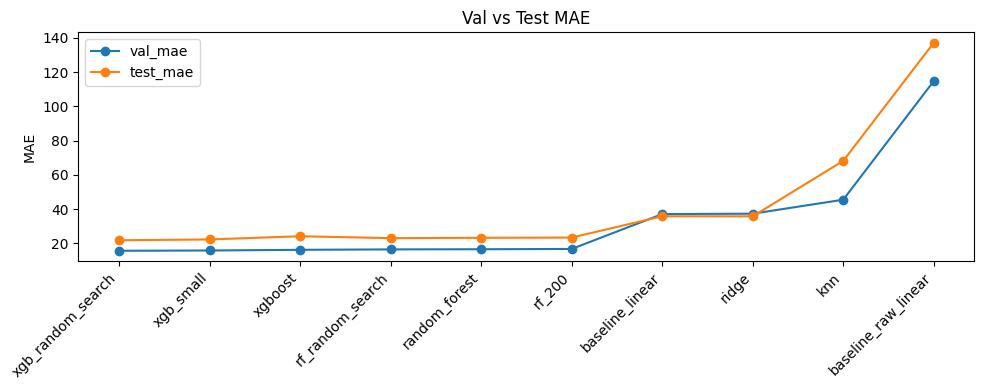

In [20]:
plt.figure(figsize=(10, 4))
plt.plot(cmp['model'], cmp['val_mae'], marker='o', label='val_mae')
plt.plot(cmp['model'], cmp['test_mae'], marker='o', label='test_mae')
plt.xticks(rotation=45, ha='right')
plt.ylabel('MAE')
plt.title('Val vs Test MAE')
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
cmp['generalization_gap'] = cmp['test_mae'] - cmp['val_mae']
cmp[['model', 'generalization_gap']].sort_values('generalization_gap')

,model,generalization_gap
7,ridge,-1.549590
6,baseline_linear,-1.275080
0,xgb_random_search,6.161489
1,xgb_small,6.451733
3,rf_random_search,6.576036
5,rf_200,6.639347
4,random_forest,6.680018
2,xgboost,7.938419
9,baseline_raw_linear,22.390378
8,knn,22.703251


Вывод: по `val_mae` лучше `xgb_small`, при этом отрыв от остальных ансамблей устойчивый, а baseline без FE сильно проигрывает

## Дальше

- Углубить подбор гиперпараметров: увеличить число конфигураций для XGBoost/RandomForest
- Добавить проверку стабильности
- Сравнить качество и время обучения, чтобы выбрать модель не только по MAE, но и по практичности

## Системный тюнинг гиперпараметров

Используем автоматизированный подбор:

- `RandomizedSearchCV`
- валидация через `TimeSeriesSplit`
- сравнение лучших tuned-моделей с ручными конфигурациями

In [22]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
import pandas as pd

ROOT = Path('..')
train_df = pd.read_csv(ROOT / 'data' / 'processed' / 'train_processed.csv')
val_df = pd.read_csv(ROOT / 'data' / 'processed' / 'val_processed.csv')

target = 'nat_demand'
drop = [target, 'datetime', 'Datetime', 'date', 'Date', 'timestamp', 'Timestamp']
feats = [c for c in train_df.columns if c not in drop]

x_train, y_train = train_df[feats], train_df[target]
x_val, y_val = val_df[feats], val_df[target]

ts_cv = TimeSeriesSplit(n_splits=3)

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions={
        'n_estimators': [200, 300, 400],
        'max_depth': [10, 14, 18, None],
        'min_samples_split': [2, 4, 8],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', None],
    },
    n_iter=6,
    scoring='neg_mean_absolute_error',
    cv=ts_cv,
    random_state=42,
    n_jobs=-1,
)
rf_search.fit(x_train, y_train)

xgb_search = RandomizedSearchCV(
    XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1),
    param_distributions={
        'n_estimators': [180, 260, 340],
        'learning_rate': [0.04, 0.06, 0.08],
        'max_depth': [4, 5, 6],
        'subsample': [0.8, 0.9, 1.0],
        'colsample_bytree': [0.8, 0.9, 1.0],
        'min_child_weight': [1, 3, 5],
        'reg_lambda': [1.0, 3.0, 6.0],
    },
    n_iter=7,
    scoring='neg_mean_absolute_error',
    cv=ts_cv,
    random_state=42,
    n_jobs=-1,
)
xgb_search.fit(x_train, y_train)

rf_val_mae = mean_absolute_error(y_val, rf_search.best_estimator_.predict(x_val))
xgb_val_mae = mean_absolute_error(y_val, xgb_search.best_estimator_.predict(x_val))

print('rf best params:', rf_search.best_params_)
print('rf tuned val_mae:', rf_val_mae)
print('xgb best params:', xgb_search.best_params_)
print('xgb tuned val_mae:', xgb_val_mae)

rf best params: {'n_estimators': 200, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': None}
rf tuned val_mae: 16.477128588840777
xgb best params: {'subsample': 0.8, 'reg_lambda': 1.0, 'n_estimators': 340, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.04, 'colsample_bytree': 1.0}
xgb tuned val_mae: 15.682111310079677


## Уменьшение размерности (PCA)

`StandardScaler + PCA + LinearRegression` и сравним с `baseline_linear` на full features

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

n_components = min(10, x_train.shape[1])
pca_model = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=n_components, random_state=42)),
    ('model', LinearRegression()),
])

pca_model.fit(x_train, y_train)
val_pred_pca = pca_model.predict(x_val)

print('PCA + Linear val_mae:', mean_absolute_error(y_val, val_pred_pca))
print('PCA + Linear val_rmse:', np.sqrt(mean_squared_error(y_val, val_pred_pca)))
print('n_components:', n_components)

PCA + Linear val_mae: 56.42686428966392
PCA + Linear val_rmse: 72.3693878162473
n_components: 10
